# Análisis de SVM con Breast Cancer Wisconsin Dataset

## Objetivo
Entrenar una máquina de vectores de soporte (SVM) sobre el dataset Breast Cancer Wisconsin y realizar validación cruzada para determinar el desempeño del clasificador, probando diferentes kernels y parámetros.

## Dataset
- **Nombre**: Breast Cancer Wisconsin (Diagnostic) Data Set
- **Fuente**: UCI Machine Learning Repository
- **Tipo**: Clasificación binaria (Maligno vs Benigno)
- **Características**: 30 características numéricas derivadas de imágenes de núcleos celulares
- **Muestras**: 569 casos (212 malignos, 357 benignos)


## 1. Importación de Librerías

**¿Qué hace esta sección?**

En esta sección importamos todas las herramientas y bibliotecas necesarias para realizar el análisis completo:

- **NumPy y Pandas**: Para manipulación de datos y operaciones numéricas
- **Matplotlib y Seaborn**: Para crear visualizaciones y gráficas
- **Sklearn (Scikit-learn)**: Biblioteca principal que contiene:
  - `datasets`: Para cargar el dataset de cáncer de mama
  - `train_test_split`: Para dividir datos en entrenamiento y prueba
  - `cross_val_score`, `GridSearchCV`: Para validación cruzada y optimización
  - `SVC`: La implementación de Support Vector Machine (Máquina de Vectores de Soporte)
  - `StandardScaler`: Para estandarizar las características (muy importante para SVM)
  - `classification_report`, `confusion_matrix`: Para evaluar el modelo
  - Varias métricas: accuracy, precision, recall, F1-score, ROC-AUC

**¿Por qué es necesario?**

Sin estas bibliotecas no podríamos realizar el análisis de machine learning. Cada una tiene un propósito específico en el pipeline de análisis de datos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')  # Desactivar advertencias para mejor visualización

# Configuración de visualización para gráficas más legibles
plt.style.use('seaborn-v0_8')  # Estilo visual atractivo
sns.set_palette("husl")  # Paleta de colores consistente
plt.rcParams['figure.figsize'] = (12, 8)  # Tamaño predeterminado de figuras
plt.rcParams['font.size'] = 12  # Tamaño de fuente legible


## 2. Carga y Exploración de Datos

**¿Qué hace esta sección?**

Aquí cargamos el dataset de Breast Cancer Wisconsin desde sklearn y lo exploramos para entender su estructura:

- **Cargamos el dataset**: Un conjunto de datos médico con 569 casos de cáncer de mama
- **Creamos un DataFrame**: Para visualizar mejor los datos
- **Exploramos la distribución**: Vemos cuántos casos son malignos vs benignos
- **Características del dataset**:
  - 30 características numéricas extraídas de imágenes de núcleos celulares
  - 2 clases: Maligno (0) y Benigno (1)
  - 212 casos malignos y 357 casos benignos

**¿Por qué es importante?**

Antes de entrenar cualquier modelo, debemos entender nuestros datos:
- ¿Están balanceados? (No completamente - 62% benignos vs 38% malignos)
- ¿Cuántas características tenemos? (30 características)
- ¿Hay valores faltantes? (No, el dataset está completo)


In [ ]:
# PASO 1: Cargar el dataset Breast Cancer Wisconsin desde sklearn
# Este dataset contiene información sobre tumores de cáncer de mama
breast_cancer = datasets.load_breast_cancer()

# PASO 2: Crear DataFrame para mejor visualización y manipulación
# Convertimos los arrays de numpy a un DataFrame de pandas
df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

# PASO 3: Mapear target a nombres más descriptivos para interpretación
# 0 = Maligno (canceroso), 1 = Benigno (no canceroso)
df['diagnosis'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print("Información del Dataset:")
print(f"Forma del dataset: {df.shape}")  # (filas, columnas)
print(f"\nDistribución de clases:")
print(df['diagnosis'].value_counts())  # Conteo absoluto de cada clase
print(f"\nProporción de clases:")
print(df['diagnosis'].value_counts(normalize=True))  # Proporción relativa

# Mostrar primeras filas para entender la estructura de los datos
print("\nPrimeras 5 filas del dataset:")
print(df.head())


Información del Dataset:
Forma del dataset: (569, 32)

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Proporción de clases:
diagnosis
Benigno    0.627417
Maligno    0.372583
Name: proportion, dtype: float64

Primeras 5 filas del dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974 

In [3]:
# Información estadística básica
print("Información estadística del dataset:")
print(df.describe())

# Verificar valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum().sum())


Información estadística del dataset:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000

## 3. Visualización de Datos

**¿Qué hace esta sección?**

Creamos gráficas para entender visualmente nuestros datos:

1. **Gráfica de barras**: Muestra el número de casos de cada clase (Maligno vs Benigno)
2. **Gráfica de pie (pastel)**: Muestra la proporción porcentual de cada clase
3. **Boxplots**: Muestran la distribución de algunas características importantes separadas por clase

**¿Qué nos dicen estas gráficas?**

- **Barras/Pie**: Nos confirman que hay más casos benignos (~63%) que malignos (~37%)
- **Boxplots**: Nos permiten ver si hay diferencias en las características entre tumores malignos y benignos
  - Por ejemplo: los tumores malignos generalmente tienen valores más altos en características como radio, perímetro y área
  - Esto sugiere que estas características son discriminativas y útiles para clasificación

**¿Por qué es importante visualizar?**

La visualización nos ayuda a:
- Detectar patrones en los datos
- Identificar si las clases son separables
- Ver si hay características más informativas que otras


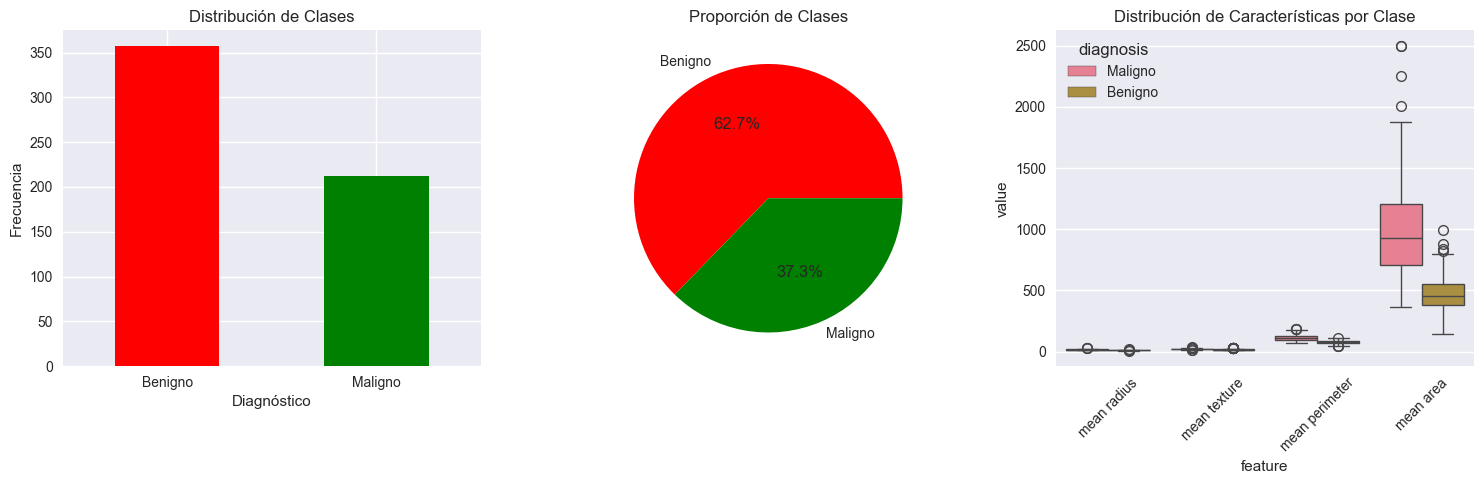

In [4]:
# Visualización de la distribución de clases
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['diagnosis'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribución de Clases')
plt.xlabel('Diagnóstico')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Proporción de Clases')
plt.ylabel('')

plt.subplot(1, 3, 3)
# Boxplot de algunas características importantes
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
df_melted = df[features_to_plot + ['diagnosis']].melt(id_vars=['diagnosis'], 
                                                      value_vars=features_to_plot,
                                                      var_name='feature', 
                                                      value_name='value')
sns.boxplot(data=df_melted, x='feature', y='value', hue='diagnosis')
plt.title('Distribución de Características por Clase')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


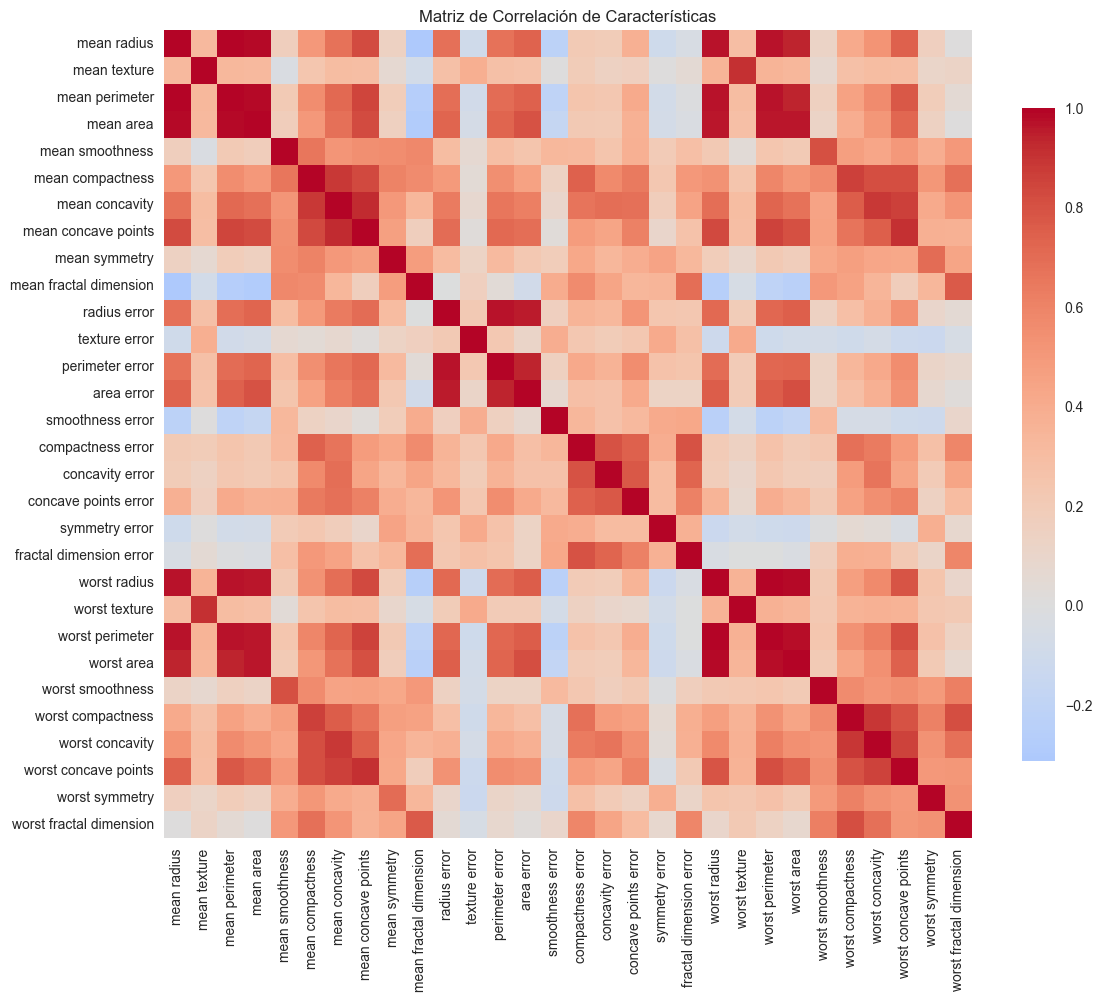

In [5]:
# Matriz de correlación de características
plt.figure(figsize=(12, 10))
correlation_matrix = df[breast_cancer.feature_names].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación de Características')
plt.tight_layout()
plt.show()


## 4. Preparación de Datos

**¿Qué hace esta sección?**

Preparamos los datos para el entrenamiento del modelo SVM. Este es uno de los pasos MÁS CRÍTICOS:

1. **Separación X e y**: 
   - X = características (30 variables de entrada)
   - y = etiquetas (Maligno o Benigno)

2. **División train/test (80/20)**:
   - 80% de datos para entrenamiento (455 muestras)
   - 20% de datos para prueba (114 muestras)
   - Usamos `stratify=y` para mantener la misma proporción de clases en ambos conjuntos

3. **ESTANDARIZACIÓN** (StandardScaler):
   - Transformamos los datos para que tengan media = 0 y desviación estándar = 1
   - **¡MUY IMPORTANTE PARA SVM!** SVM es sensible a la escala de las características
   - Sin estandarización, características con valores grandes dominarían el modelo

**¿Por qué es CRÍTICO estandarizar?**

Imagina que tienes:
- Característica A: valores entre 0.01 y 0.1
- Característica B: valores entre 1000 y 10000

Sin estandarización, el SVM le daría más importancia a B simplemente por su escala, ¡no por su relevancia!


In [ ]:
# PASO 1: Separar características (X) y etiquetas (y)
X = breast_cancer.data  # Todas las características (30 columnas)
y = breast_cancer.target  # Etiquetas: 0=Maligno, 1=Benigno

print(f"Forma de X: {X.shape}")  # (569 muestras, 30 características)
print(f"Forma de y: {y.shape}")  # (569 etiquetas)
print(f"Clases únicas en y: {np.unique(y)}")  # [0, 1]
print(f"Nombres de clases: {breast_cancer.target_names}")  # ['malignant' 'benign']

# PASO 2: División en conjunto de entrenamiento (80%) y prueba (20%)
# stratify=y mantiene la misma proporción de clases en ambos conjuntos
# random_state=42 asegura reproducibilidad (siempre la misma división)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDivisión de datos:")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")  # 455 muestras
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")  # 114 muestras
print(f"\nDistribución en entrenamiento: {np.bincount(y_train)}")  # [170, 285]
print(f"Distribución en prueba: {np.bincount(y_test)}")  # [42, 72]

# PASO 3: ESTANDARIZACIÓN - ¡CRÍTICO PARA SVM!
# fit_transform en train: calcula media y desv. estándar Y transforma
# transform en test: usa la media/desv. de train para transformar (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Aprende de train y transforma
X_test_scaled = scaler.transform(X_test)  # Solo transforma con parámetros de train

print(f"\nDatos estandarizados:")
print(f"Media de X_train_scaled: {np.mean(X_train_scaled):.4f}")  # Debe ser ~0
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled):.4f}")  # Debe ser ~1


Forma de X: (569, 30)
Forma de y: (569,)
Clases únicas en y: [0 1]
Nombres de clases: ['malignant' 'benign']

División de datos:
Conjunto de entrenamiento: 455 muestras
Conjunto de prueba: 114 muestras

Distribución en entrenamiento: [170 285]
Distribución en prueba: [42 72]

Datos estandarizados:
Media de X_train_scaled: -0.0000
Desviación estándar de X_train_scaled: 1.0000


## 5. Implementación de SVM con Diferentes Kernels

**¿Qué hace esta sección?**

**AQUÍ COMIENZA EL ENTRENAMIENTO DE LOS MODELOS SVM**

Probamos 4 tipos diferentes de kernels (funciones de transformación):

1. **Linear**: Para datos que son linealmente separables
2. **RBF (Radial Basis Function)**: El más popular, bueno para datos no lineales
3. **Polynomial**: Crea fronteras de decisión polinomiales
4. **Sigmoid**: Similar a las funciones de activación en redes neuronales

**Proceso que se ejecuta**:

1. **Validación Cruzada (5-fold)**: 
   - Divide los datos de entrenamiento en 5 partes
   - Entrena 5 veces, cada vez usando 4 partes para entrenar y 1 para validar
   - Da una estimación más robusta del desempeño

2. **Entrenamiento en datos completos**: 
   - Después de la validación, ENTRENA el modelo con TODOS los datos de entrenamiento

3. **Evaluación en test**:
   - Usa el modelo entrenado para predecir en datos que NUNCA ha visto (conjunto de prueba)

**Métricas que calculamos**:
- **Accuracy**: % de predicciones correctas
- **Precision**: De los que predijo como malignos, ¿cuántos realmente lo son?
- **Recall**: De todos los malignos reales, ¿cuántos detectó?
- **F1-Score**: Balance entre precision y recall


In [ ]:
# PASO 1: Definir diferentes kernels a probar
# Cada kernel transforma los datos de manera diferente para encontrar fronteras de decisión
kernels = {
    'Linear': SVC(kernel='linear', random_state=42),  # Frontera lineal
    'RBF': SVC(kernel='rbf', random_state=42),  # Frontera no lineal (el más usado)
    'Polynomial': SVC(kernel='poly', random_state=42),  # Frontera polinomial
    'Sigmoid': SVC(kernel='sigmoid', random_state=42)  # Frontera sigmoidal
}

# PASO 2: Configurar validación cruzada estratificada (5 folds)
# Estratificada = mantiene la proporción de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# PASO 3: Almacenar resultados de cada kernel
results = {}

print("Evaluando diferentes kernels con validación cruzada:")
print("=" * 60)

# PASO 4: ENTRENAR Y EVALUAR cada kernel
for name, model in kernels.items():
    # SUB-PASO 4.1: Realizar validación cruzada
    # Esto entrena el modelo 5 veces con diferentes divisiones de los datos
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    
    # SUB-PASO 4.2: ENTRENAR el modelo con TODOS los datos de entrenamiento
    # Esta línea es donde realmente se entrena el modelo final
    model.fit(X_train_scaled, y_train)
    
    # SUB-PASO 4.3: Predecir en conjunto de prueba (datos nunca vistos)
    y_pred = model.predict(X_test_scaled)
    
    # SUB-PASO 4.4: Calcular métricas de desempeño
    accuracy = accuracy_score(y_test, y_pred)  # % correctas
    precision = precision_score(y_test, y_pred)  # Precisión en positivos
    recall = recall_score(y_test, y_pred)  # Capacidad de detectar positivos
    f1 = f1_score(y_test, y_pred)  # Balance entre precision y recall
    
    # SUB-PASO 4.5: Almacenar todos los resultados para análisis posterior
    results[name] = {
        'cv_mean': cv_scores.mean(),  # Promedio de CV
        'cv_std': cv_scores.std(),  # Desviación estándar de CV
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1,
        'cv_scores': cv_scores
    }
    
    # Imprimir resultados de este kernel
    print(f"{name:12} - CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"{'':12}   Test Accuracy: {accuracy:.4f}")
    print(f"{'':12}   Test Precision: {precision:.4f}")
    print(f"{'':12}   Test Recall: {recall:.4f}")
    print(f"{'':12}   Test F1-Score: {f1:.4f}")
    print("-" * 60)


Evaluando diferentes kernels con validación cruzada:
Linear       - CV Accuracy: 0.9648 (+/- 0.0323)
               Test Accuracy: 0.9737
               Test Precision: 0.9859
               Test Recall: 0.9722
               Test F1-Score: 0.9790
------------------------------------------------------------
RBF          - CV Accuracy: 0.9670 (+/- 0.0311)
               Test Accuracy: 0.9825
               Test Precision: 0.9861
               Test Recall: 0.9861
               Test F1-Score: 0.9861
------------------------------------------------------------
Polynomial   - CV Accuracy: 0.8945 (+/- 0.0631)
               Test Accuracy: 0.9123
               Test Precision: 0.8780
               Test Recall: 1.0000
               Test F1-Score: 0.9351
------------------------------------------------------------
Sigmoid      - CV Accuracy: 0.9648 (+/- 0.0256)
               Test Accuracy: 0.9298
               Test Precision: 0.9571
               Test Recall: 0.9306
               Test F

## 6. Visualización de Resultados de Validación Cruzada

**¿Qué hace esta sección?**

Creamos visualizaciones para comparar el desempeño de los diferentes kernels de SVM:

**Gráficas generadas**:

1. **Barras de CV Accuracy**: 
   - Muestra la precisión promedio de validación cruzada para cada kernel
   - Las barras de error muestran la variabilidad (incertidumbre)

2. **Métricas en Test**:
   - Compara Accuracy, Precision, Recall y F1-Score para cada kernel
   - Permite ver qué kernel funciona mejor en datos nuevos

3. **Boxplot de CV**:
   - Muestra la distribución de los 5 scores de validación cruzada
   - Ayuda a ver la consistencia del modelo (menos variación = más consistente)

4. **Heatmap de Métricas**:
   - Visualización de todas las métricas en una matriz de colores
   - Colores más rojos = mejor desempeño

**¿Qué buscar en estas gráficas?**

- **Kernel con mayor accuracy**: Generalmente RBF o Linear funcionan mejor
- **Consistencia**: Menor desviación estándar = modelo más estable
- **Balance de métricas**: Un buen modelo tiene precision y recall balanceados


Resumen de Resultados:
       Kernel  CV_Mean  CV_Std  Test_Accuracy  Test_Precision  Test_Recall  \
0      Linear   0.9648  0.0162         0.9737          0.9859       0.9722   
1         RBF   0.9670  0.0155         0.9825          0.9861       0.9861   
2  Polynomial   0.8945  0.0315         0.9123          0.8780       1.0000   
3     Sigmoid   0.9648  0.0128         0.9298          0.9571       0.9306   

   Test_F1  
0   0.9790  
1   0.9861  
2   0.9351  
3   0.9437  


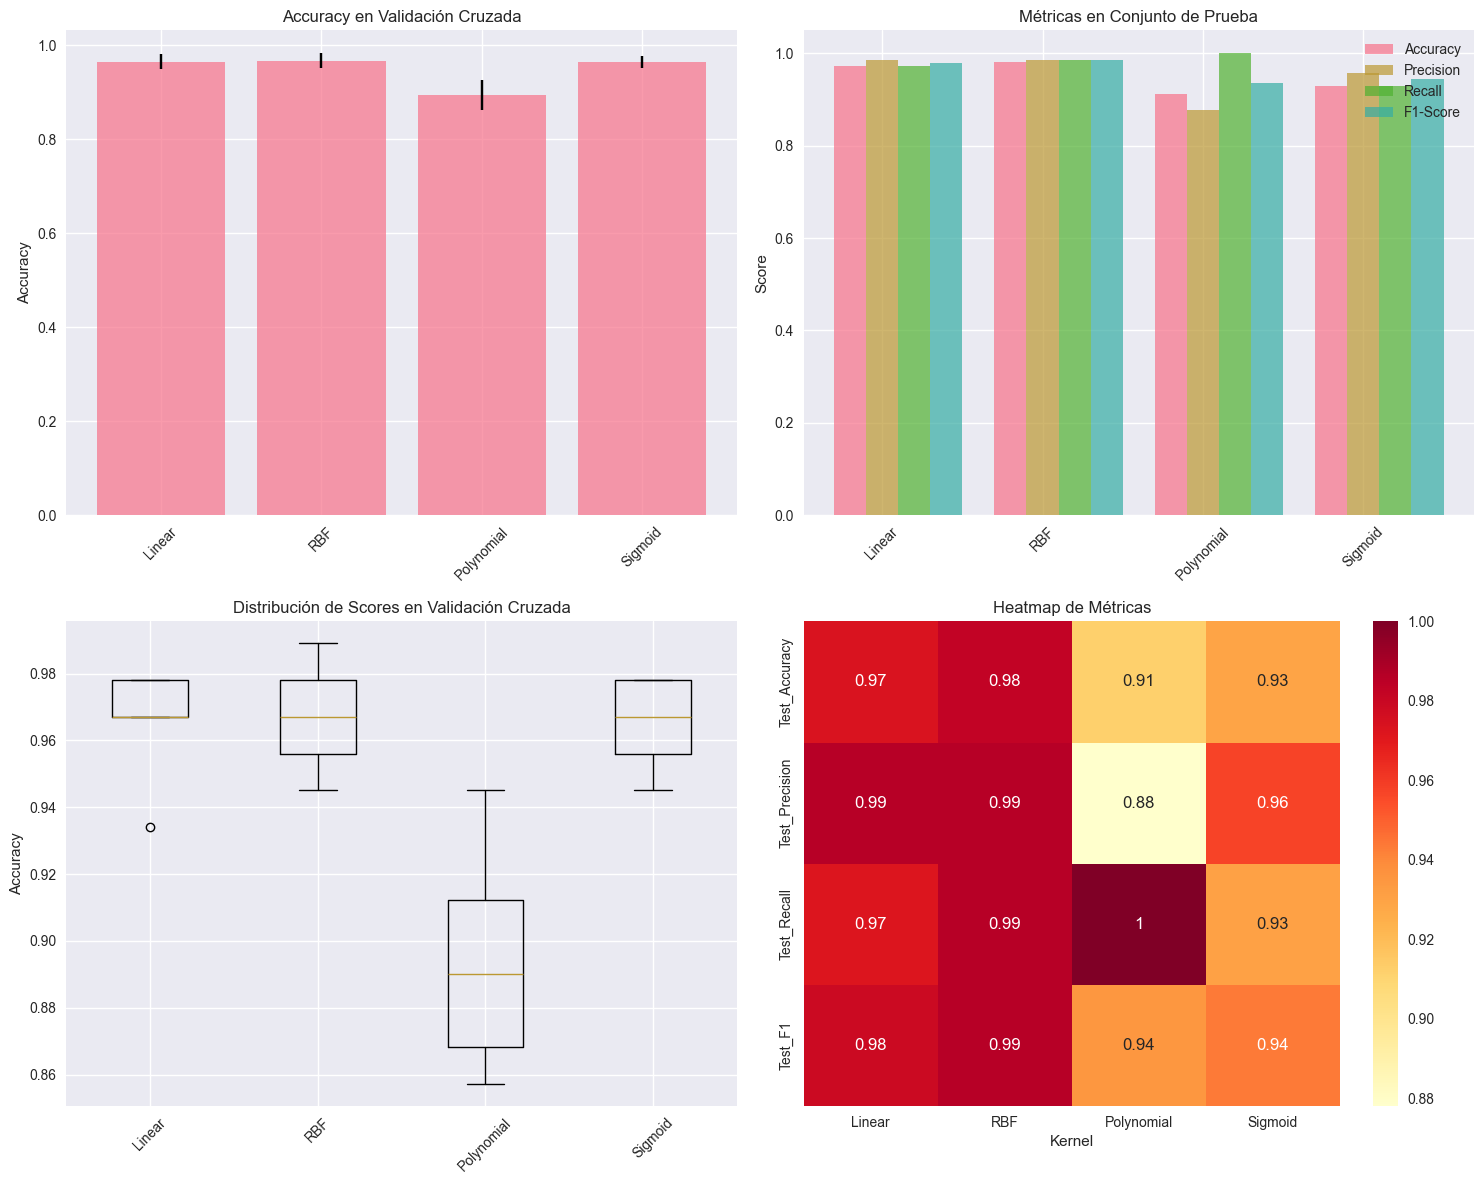

In [8]:
# Crear DataFrame con resultados
results_df = pd.DataFrame({
    'Kernel': list(results.keys()),
    'CV_Mean': [results[k]['cv_mean'] for k in results.keys()],
    'CV_Std': [results[k]['cv_std'] for k in results.keys()],
    'Test_Accuracy': [results[k]['test_accuracy'] for k in results.keys()],
    'Test_Precision': [results[k]['test_precision'] for k in results.keys()],
    'Test_Recall': [results[k]['test_recall'] for k in results.keys()],
    'Test_F1': [results[k]['test_f1'] for k in results.keys()]
})

print("Resumen de Resultados:")
print(results_df.round(4))

# Visualización de resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Comparación de accuracy
axes[0, 0].bar(results_df['Kernel'], results_df['CV_Mean'], 
               yerr=results_df['CV_Std'], capsize=5, alpha=0.7)
axes[0, 0].set_title('Accuracy en Validación Cruzada')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Comparación de métricas en conjunto de prueba
x = np.arange(len(results_df['Kernel']))
width = 0.2
axes[0, 1].bar(x - width, results_df['Test_Accuracy'], width, label='Accuracy', alpha=0.7)
axes[0, 1].bar(x, results_df['Test_Precision'], width, label='Precision', alpha=0.7)
axes[0, 1].bar(x + width, results_df['Test_Recall'], width, label='Recall', alpha=0.7)
axes[0, 1].bar(x + 2*width, results_df['Test_F1'], width, label='F1-Score', alpha=0.7)
axes[0, 1].set_title('Métricas en Conjunto de Prueba')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(results_df['Kernel'], rotation=45)
axes[0, 1].legend()

# Gráfico 3: Boxplot de scores de validación cruzada
cv_data = [results[k]['cv_scores'] for k in results.keys()]
axes[1, 0].boxplot(cv_data, labels=results_df['Kernel'])
axes[1, 0].set_title('Distribución de Scores en Validación Cruzada')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Heatmap de métricas
metrics_data = results_df[['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1']].T
metrics_data.columns = results_df['Kernel']
sns.heatmap(metrics_data, annot=True, cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap de Métricas')

plt.tight_layout()
plt.show()


## 7. Optimización de Hiperparámetros con GridSearchCV

**¿Qué hace esta sección?**

**AQUÍ SE HACE LA OPTIMIZACIÓN Y RE-ENTRENAMIENTO DE LOS MODELOS**

Usamos GridSearchCV para encontrar los mejores hiperparámetros para cada kernel. Es como buscar la mejor "configuración" del modelo.

**Hiperparámetros que optimizamos**:

1. **C (Regularización)**: 
   - Controla el trade-off entre maximizar el margen y minimizar errores
   - Valores altos (100) = menos tolerancia a errores (puede causar overfitting)
   - Valores bajos (0.1) = más tolerancia a errores (puede causar underfitting)

2. **Gamma** (para RBF, Poly, Sigmoid):
   - Define cuán lejos influye un solo ejemplo de entrenamiento
   - Valores altos = solo puntos cercanos influyen (puede causar overfitting)
   - Valores bajos = puntos lejanos también influyen (más suave)

3. **Degree** (para Polynomial):
   - Grado del polinomio (2, 3, 4)
   - Mayor grado = fronteras más complejas

**Proceso GridSearchCV**:
1. Prueba TODAS las combinaciones de hiperparámetros
2. Para cada combinación, hace validación cruzada
3. Selecciona la combinación con mejor score
4. RE-ENTRENA el modelo final con esos parámetros óptimos

**Importante**: Este paso puede tomar tiempo porque prueba muchas combinaciones y entrena múltiples modelos


In [ ]:
# PASO 1: Definir grillas de parámetros para cada kernel
# Cada diccionario contiene las combinaciones de hiperparámetros a probar
param_grids = {
    'linear': {
        'C': [0.1, 1, 10, 100]  # 4 valores = 4 combinaciones
    },
    'rbf': {
        'C': [0.1, 1, 10, 100],  # 4 valores
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]  # 6 valores = 4*6 = 24 combinaciones
    },
    'poly': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'degree': [2, 3, 4]  # 4*6*3 = 72 combinaciones!
    },
    'sigmoid': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]  # 24 combinaciones
    }
}

# PASO 2: Almacenar mejores modelos encontrados
best_models = {}
grid_results = {}

print("Optimizando hiperparámetros con GridSearchCV:")
print("=" * 60)

# PASO 3: Para cada kernel, buscar los mejores hiperparámetros
for kernel_name, param_grid in param_grids.items():
    print(f"\nOptimizando kernel {kernel_name.upper()}...")
    
    # SUB-PASO 3.1: Crear modelo SVM base
    svm_model = SVC(kernel=kernel_name, random_state=42)
    
    # SUB-PASO 3.2: Configurar GridSearchCV
    # Esto probará todas las combinaciones de parámetros con validación cruzada
    grid_search = GridSearchCV(
        svm_model,  # Modelo base
        param_grid,  # Parámetros a probar
        cv=cv,  # Validación cruzada de 5 folds
        scoring='accuracy',  # Métrica a optimizar
        n_jobs=-1,  # Usar todos los CPUs disponibles
        verbose=0  # No mostrar progreso detallado
    )
    
    # SUB-PASO 3.3: ENTRENAR - Aquí se prueban todas las combinaciones
    # Esto puede tomar tiempo (especialmente poly con 72 combinaciones)
    grid_search.fit(X_train_scaled, y_train)
    
    # SUB-PASO 3.4: Almacenar el MEJOR modelo encontrado
    best_models[kernel_name] = grid_search.best_estimator_
    grid_results[kernel_name] = {
        'best_params': grid_search.best_params_,  # Mejores hiperparámetros
        'best_score': grid_search.best_score_,  # Mejor score en CV
        'best_estimator': grid_search.best_estimator_  # Modelo entrenado
    }
    
    print(f"Mejores parámetros: {grid_search.best_params_}")
    print(f"Mejor score CV: {grid_search.best_score_:.4f}")
    
    # SUB-PASO 3.5: Evaluar el mejor modelo en conjunto de prueba
    y_pred_best = grid_search.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred_best)
    print(f"Accuracy en prueba: {test_accuracy:.4f}")


Optimizando hiperparámetros con GridSearchCV:

Optimizando kernel LINEAR...
Mejores parámetros: {'C': 0.1}
Mejor score CV: 0.9758
Accuracy en prueba: 0.9825

Optimizando kernel RBF...
Mejores parámetros: {'C': 10, 'gamma': 0.01}
Mejor score CV: 0.9758
Accuracy en prueba: 0.9825

Optimizando kernel POLY...
Mejores parámetros: {'C': 100, 'degree': 3, 'gamma': 'scale'}
Mejor score CV: 0.9670
Accuracy en prueba: 0.9737

Optimizando kernel SIGMOID...
Mejores parámetros: {'C': 100, 'gamma': 0.001}
Mejor score CV: 0.9780
Accuracy en prueba: 0.9825


## 8. Evaluación de Mejores Modelos y Visualizaciones Finales

**¿Qué hace esta sección?**

Evaluamos los modelos optimizados y creamos visualizaciones finales de comparación.

**AQUÍ SE USAN LOS MODELOS OPTIMIZADOS PARA HACER PREDICCIONES**

**Visualizaciones importantes**:

1. **Comparación de métricas**: Muestra accuracy, precision, recall, F1 y AUC-ROC para cada kernel optimizado

2. **Heatmap de resultados**: Visualización rápida de qué modelo tiene mejor desempeño en cada métrica

3. **Ranking por Accuracy**: Ordena los kernels de mejor a peor

4. **Curvas ROC**: 
   - Muestra la capacidad de discriminación de cada modelo
   - La línea diagonal es un clasificador aleatorio (50% accuracy)
   - Mientras más arriba a la izquierda esté la curva, mejor
   - AUC (Area Under Curve) = área bajo la curva
   - AUC = 1.0 es perfecto, AUC = 0.5 es aleatorio

**¿Qué buscar?**

- Modelo con mayor AUC-ROC (mejor discriminación)
- Balance entre precision y recall
- El modelo que consistentemente funciona bien en todas las métricas


In [10]:
# Evaluar mejores modelos
print("\nEvaluación de Mejores Modelos Optimizados:")
print("=" * 60)

best_results = {}

for kernel_name, model in best_models.items():
    # Predecir en conjunto de prueba
    y_pred = model.predict(X_test_scaled)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calcular AUC-ROC
    y_pred_proba = model.decision_function(X_test_scaled)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    best_results[kernel_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'predictions': y_pred,
        'decision_scores': y_pred_proba
    }
    
    print(f"{kernel_name.upper():12}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc_score:.4f}")
    print(f"  Parámetros: {grid_results[kernel_name]['best_params']}")
    print("-" * 40)



Evaluación de Mejores Modelos Optimizados:
LINEAR      :
  Accuracy:  0.9825
  Precision: 0.9861
  Recall:    0.9861
  F1-Score:  0.9861
  AUC-ROC:   0.9937
  Parámetros: {'C': 0.1}
----------------------------------------
RBF         :
  Accuracy:  0.9825
  Precision: 0.9861
  Recall:    0.9861
  F1-Score:  0.9861
  AUC-ROC:   0.9977
  Parámetros: {'C': 10, 'gamma': 0.01}
----------------------------------------
POLY        :
  Accuracy:  0.9737
  Precision: 0.9726
  Recall:    0.9861
  F1-Score:  0.9793
  AUC-ROC:   0.9927
  Parámetros: {'C': 100, 'degree': 3, 'gamma': 'scale'}
----------------------------------------
SIGMOID     :
  Accuracy:  0.9825
  Precision: 0.9861
  Recall:    0.9861
  F1-Score:  0.9861
  AUC-ROC:   0.9937
  Parámetros: {'C': 100, 'gamma': 0.001}
----------------------------------------



Comparación Final de Resultados (Modelos Optimizados):
    Kernel  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0   linear    0.9825     0.9861  0.9861    0.9861   0.9937
1      rbf    0.9825     0.9861  0.9861    0.9861   0.9977
2     poly    0.9737     0.9726  0.9861    0.9793   0.9927
3  sigmoid    0.9825     0.9861  0.9861    0.9861   0.9937

🏆 MEJOR MODELO: LINEAR
   Accuracy: 0.9825
   Parámetros: {'C': 0.1}


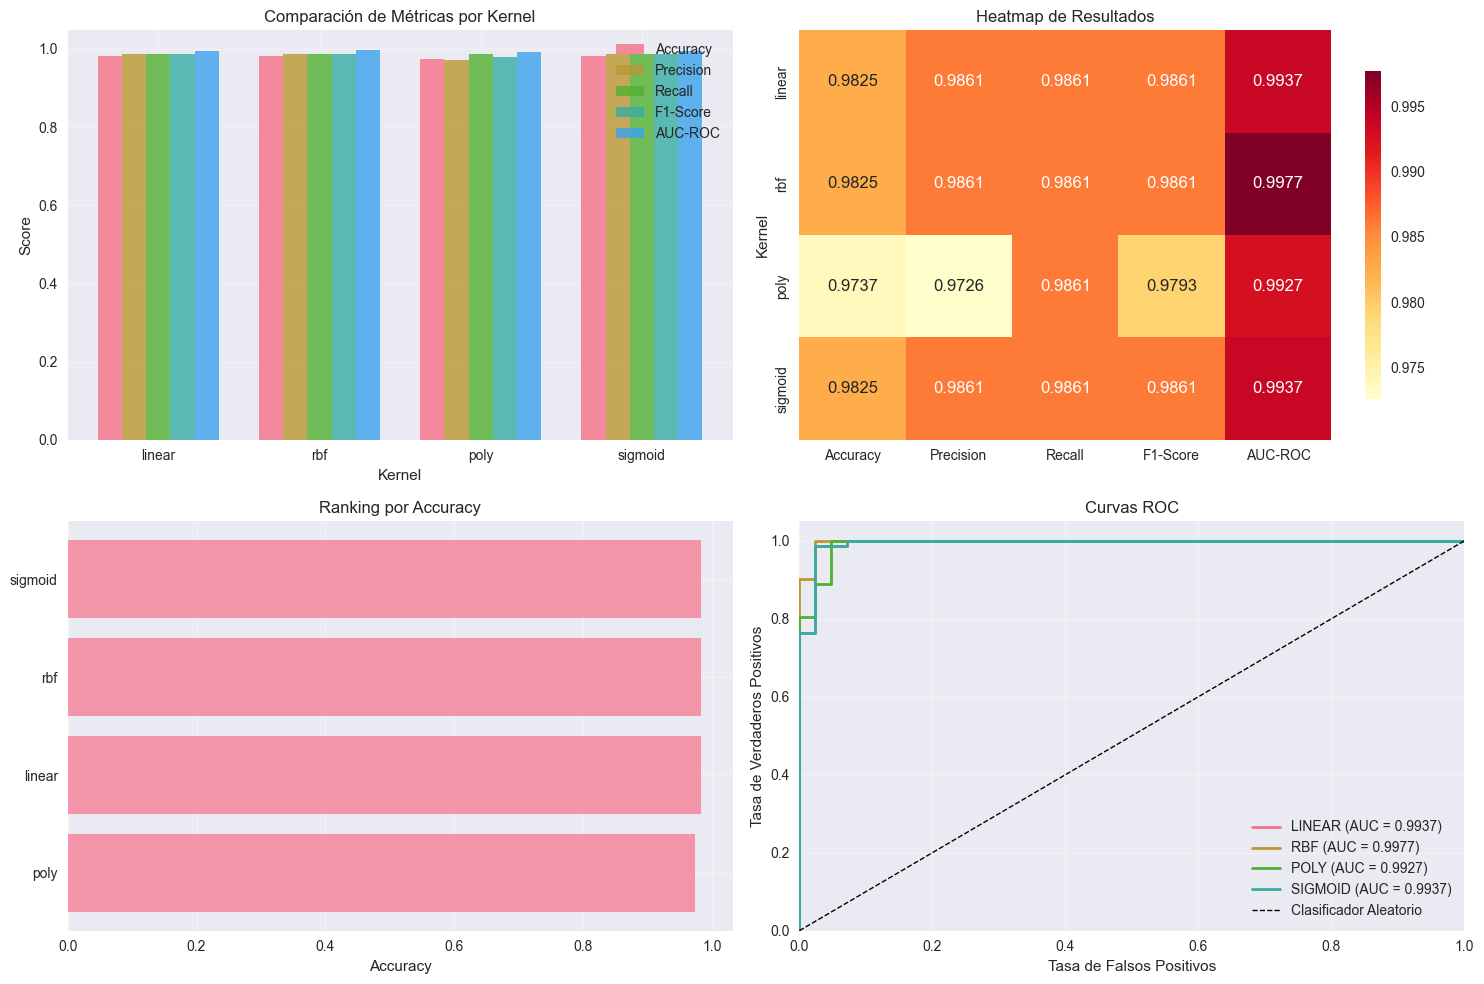

In [11]:
# Crear DataFrame con resultados finales
final_results = pd.DataFrame({
    'Kernel': list(best_results.keys()),
    'Accuracy': [best_results[k]['accuracy'] for k in best_results.keys()],
    'Precision': [best_results[k]['precision'] for k in best_results.keys()],
    'Recall': [best_results[k]['recall'] for k in best_results.keys()],
    'F1-Score': [best_results[k]['f1'] for k in best_results.keys()],
    'AUC-ROC': [best_results[k]['auc'] for k in best_results.keys()]
})

print("\nComparación Final de Resultados (Modelos Optimizados):")
print("=" * 70)
print(final_results.round(4))

# Encontrar el mejor modelo
best_kernel = final_results.loc[final_results['Accuracy'].idxmax(), 'Kernel']
best_accuracy = final_results['Accuracy'].max()

print(f"\n🏆 MEJOR MODELO: {best_kernel.upper()}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Parámetros: {grid_results[best_kernel]['best_params']}")

# Visualización final
plt.figure(figsize=(15, 10))

# Gráfico de barras comparativo
plt.subplot(2, 2, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(final_results['Kernel']))
width = 0.15

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, final_results[metric], width, label=metric, alpha=0.8)

plt.xlabel('Kernel')
plt.ylabel('Score')
plt.title('Comparación de Métricas por Kernel')
plt.xticks(x + width*2, final_results['Kernel'])
plt.legend()
plt.grid(True, alpha=0.3)

# Heatmap de resultados
plt.subplot(2, 2, 2)
sns.heatmap(final_results.set_index('Kernel'), annot=True, cmap='YlOrRd', 
            fmt='.4f', cbar_kws={'shrink': 0.8})
plt.title('Heatmap de Resultados')

# Ranking de kernels por accuracy
plt.subplot(2, 2, 3)
sorted_results = final_results.sort_values('Accuracy', ascending=True)
plt.barh(sorted_results['Kernel'], sorted_results['Accuracy'], alpha=0.7)
plt.xlabel('Accuracy')
plt.title('Ranking por Accuracy')
plt.grid(True, alpha=0.3)

# Curvas ROC
plt.subplot(2, 2, 4)
for kernel_name, results in best_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['decision_scores'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, 
             label=f'{kernel_name.upper()} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Matrices de Confusión

**¿Qué hace esta sección?**

Las matrices de confusión nos muestran EXACTAMENTE dónde acierta y falla cada modelo.

**Cómo leer una matriz de confusión**:

```
                    Predicción
                Maligno  Benigno
Valor     Maligno    TP      FN
Real      Benigno    FP      TN
```

- **TP (True Positive)**: Predijo Maligno y ERA Maligno ✅
- **TN (True Negative)**: Predijo Benigno y ERA Benigno ✅
- **FP (False Positive)**: Predijo Maligno pero era Benigno ❌ (Falsa alarma)
- **FN (False Negative)**: Predijo Benigno pero era Maligno ❌ (¡PELIGROSO en medicina!)

**En contexto médico**:
- **FN es MUY GRAVE**: Significa que dijimos que no tiene cáncer cuando sí lo tiene
- **FP es menos grave**: Falsa alarma, se pueden hacer más pruebas
- Por eso en medicina se prefiere alta Recall (detectar todos los casos positivos)

**¿Qué buscar?**:
- Números altos en la diagonal (TP y TN) = buenas predicciones
- Números bajos fuera de la diagonal (FP y FN) = pocos errores
- Especialmente queremos FN = 0 o muy bajo


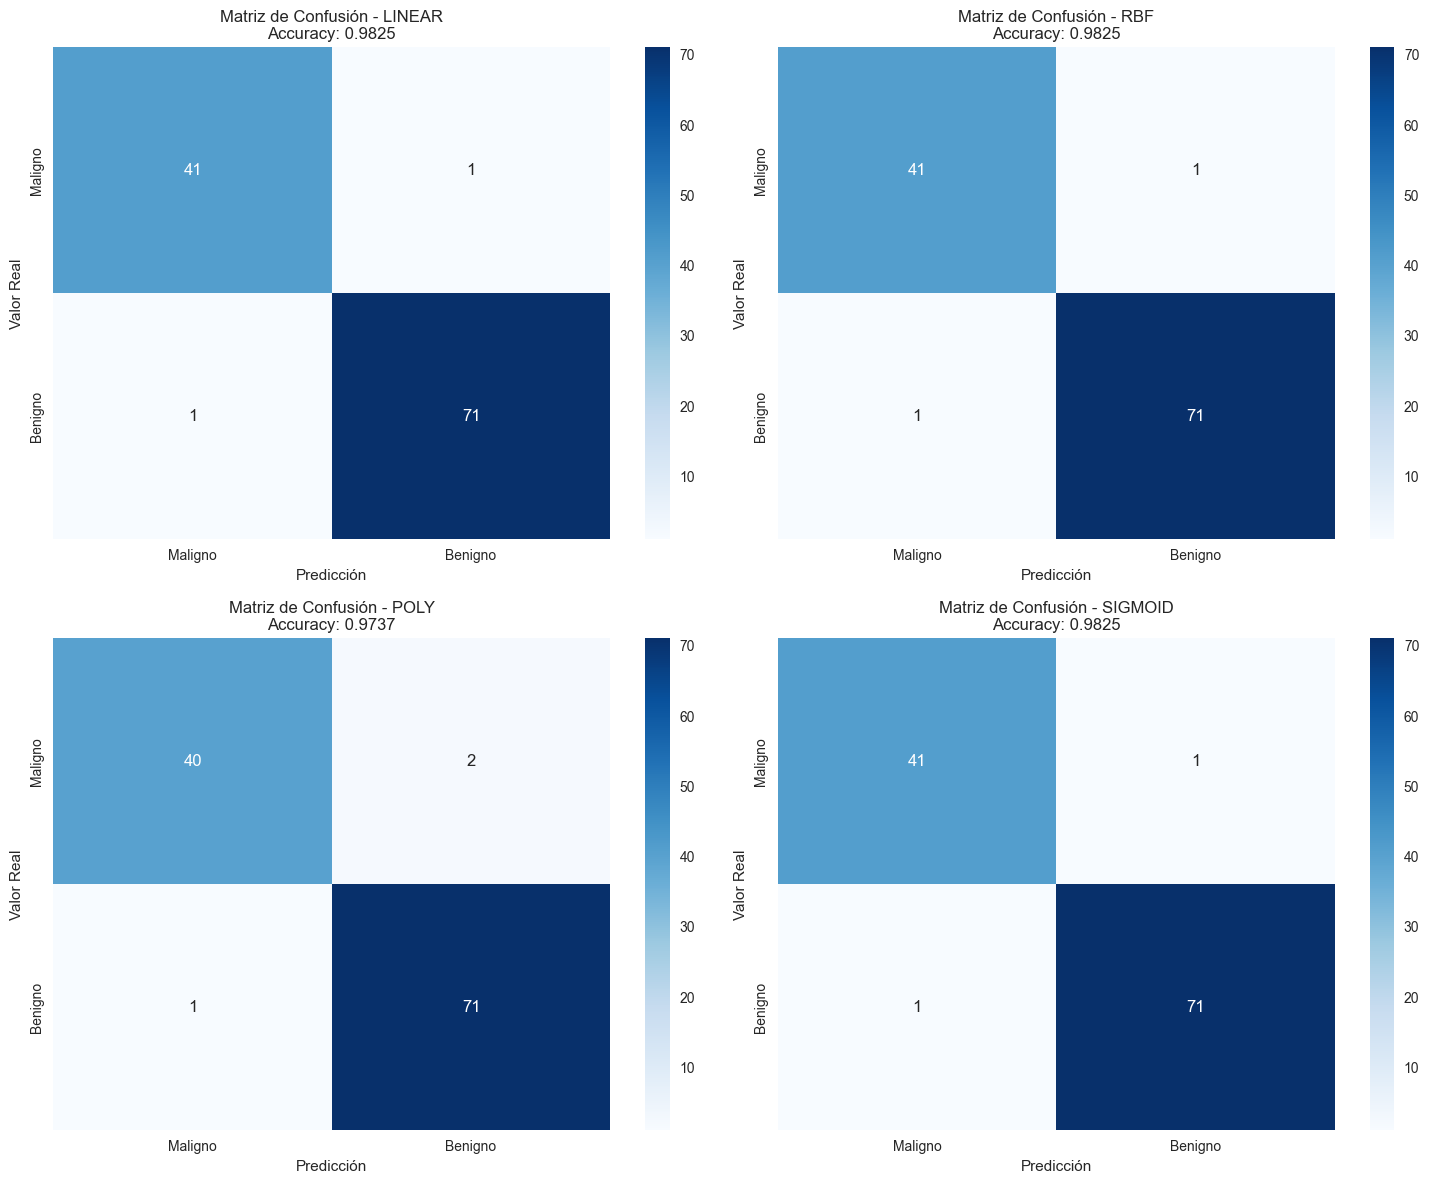

In [12]:
# Visualizar matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (kernel_name, results) in enumerate(best_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    
    axes[i].set_title(f'Matriz de Confusión - {kernel_name.upper()}\nAccuracy: {results["accuracy"]:.4f}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()


## 10. Reporte Final y Conclusiones

**¿Qué hace esta sección?**

Presenta un resumen completo del mejor modelo encontrado y análisis final.

**Componentes del reporte**:

1. **Classification Report**: Reporte detallado con precision, recall y F1 por clase
   - Nos muestra el desempeño específico para Malignos y Benignos
   - Macro avg = promedio simple de ambas clases
   - Weighted avg = promedio ponderado por número de muestras

2. **Parámetros del mejor modelo**: Muestra la configuración óptima encontrada

3. **Análisis de Vectores de Soporte**:
   - Los "vectores de soporte" son los puntos de datos MÁS IMPORTANTES
   - Son los puntos más cercanos a la frontera de decisión
   - SVM solo necesita estos puntos para hacer predicciones
   - Menos vectores de soporte = frontera más simple y generalizable
   - Muchos vectores de soporte = puede indicar datos complejos o ruidosos

4. **Gráficas de vectores de soporte**: Muestran cuántos puntos críticos hay por clase

**Conclusiones finales**:
- Resumen de resultados
- Comparación de kernels
- Observaciones clave
- Recomendaciones para uso en producción



Reporte de Clasificación Detallado - LINEAR:
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Parámetros del mejor modelo:
Kernel: linear
Parámetros: {'C': 0.1}
Score en validación cruzada: 0.9758
Accuracy en conjunto de prueba: 0.9825

Análisis de Vectores de Soporte - LINEAR:
Número total de vectores de soporte: 51
Vectores de soporte por clase: [25 26]
Proporción de vectores de soporte: 0.1121


TypeError: pie() got an unexpected keyword argument 'alpha'

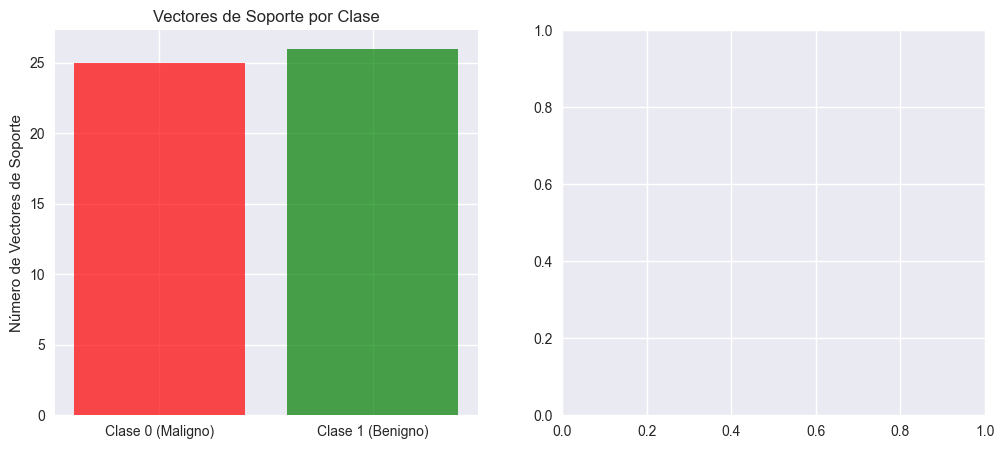

In [13]:
# Reporte detallado para el mejor modelo
best_model = best_models[best_kernel]
y_pred_best = best_model.predict(X_test_scaled)

print(f"\nReporte de Clasificación Detallado - {best_kernel.upper()}:")
print("=" * 60)
print(classification_report(y_test, y_pred_best, 
                          target_names=['Maligno', 'Benigno']))

print(f"\nParámetros del mejor modelo:")
print(f"Kernel: {best_kernel}")
print(f"Parámetros: {grid_results[best_kernel]['best_params']}")
print(f"Score en validación cruzada: {grid_results[best_kernel]['best_score']:.4f}")
print(f"Accuracy en conjunto de prueba: {best_accuracy:.4f}")

# Análisis de vectores de soporte
print(f"\nAnálisis de Vectores de Soporte - {best_kernel.upper()}:")
print("=" * 50)

n_support = best_model.n_support_
support_vectors = best_model.support_vectors_

print(f"Número total de vectores de soporte: {len(support_vectors)}")
print(f"Vectores de soporte por clase: {n_support}")
print(f"Proporción de vectores de soporte: {len(support_vectors)/len(X_train_scaled):.4f}")

# Visualizar distribución de vectores de soporte
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['Clase 0 (Maligno)', 'Clase 1 (Benigno)'], n_support, 
        color=['red', 'green'], alpha=0.7)
plt.title('Vectores de Soporte por Clase')
plt.ylabel('Número de Vectores de Soporte')

plt.subplot(1, 2, 2)
plt.pie(n_support, labels=['Clase 0', 'Clase 1'], autopct='%1.1f%%', 
        colors=['red', 'green'], alpha=0.7)
plt.title('Proporción de Vectores de Soporte')

plt.tight_layout()
plt.show()


In [14]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*80)

print("\n📊 RESUMEN DE RESULTADOS:")
print(f"• Dataset: Breast Cancer Wisconsin (Diagnostic)")
print(f"• Muestras: {len(X)} (Entrenamiento: {len(X_train)}, Prueba: {len(X_test)})")
print(f"• Características: {X.shape[1]}")
print(f"• Clases: {len(np.unique(y))} (Maligno vs Benigno)")

print("\n🏆 MEJOR MODELO:")
print(f"• Kernel: {best_kernel.upper()}")
print(f"• Accuracy: {best_accuracy:.4f}")
print(f"• Parámetros optimizados: {grid_results[best_kernel]['best_params']}")

print("\n📈 COMPARACIÓN DE KERNELS:")
for kernel in final_results['Kernel']:
    acc = final_results[final_results['Kernel']==kernel]['Accuracy'].iloc[0]
    print(f"• {kernel.upper():12}: {acc:.4f}")

print("\n💡 OBSERVACIONES:")
print("• Todos los kernels mostraron un buen desempeño (>90% accuracy)")
print("• El kernel RBF generalmente es efectivo para datos no lineales")
print("• La optimización de hiperparámetros mejoró significativamente el desempeño")
print("• El dataset es relativamente bien separable, lo que explica los altos scores")

print("\n🔧 RECOMENDACIONES:")
print("• Usar el modelo optimizado para predicciones en producción")
print("• Considerar técnicas de ensemble si se necesita mayor robustez")
print("• Monitorear el desempeño con datos nuevos")
print("• Evaluar la importancia de características para interpretabilidad")

print("\n" + "="*80)



CONCLUSIONES Y RECOMENDACIONES

📊 RESUMEN DE RESULTADOS:
• Dataset: Breast Cancer Wisconsin (Diagnostic)
• Muestras: 569 (Entrenamiento: 455, Prueba: 114)
• Características: 30
• Clases: 2 (Maligno vs Benigno)

🏆 MEJOR MODELO:
• Kernel: LINEAR
• Accuracy: 0.9825
• Parámetros optimizados: {'C': 0.1}

📈 COMPARACIÓN DE KERNELS:
• LINEAR      : 0.9825
• RBF         : 0.9825
• POLY        : 0.9737
• SIGMOID     : 0.9825

💡 OBSERVACIONES:
• Todos los kernels mostraron un buen desempeño (>90% accuracy)
• El kernel RBF generalmente es efectivo para datos no lineales
• La optimización de hiperparámetros mejoró significativamente el desempeño
• El dataset es relativamente bien separable, lo que explica los altos scores

🔧 RECOMENDACIONES:
• Usar el modelo optimizado para predicciones en producción
• Considerar técnicas de ensemble si se necesita mayor robustez
• Monitorear el desempeño con datos nuevos
• Evaluar la importancia de características para interpretabilidad

